In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports done")

✅ Imports done


In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Load data
# ═══════════════════════════════════════════════════════════
train_df = pd.read_csv("../data/raw/train.csv")

# Separate features from target
X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]

print(f"  Train shape    : {train_df.shape}")
print(f"  X_train shape  : {X_train.shape}")
print(f"  y_train shape  : {y_train.shape}")
print(f"  Fraud count    : {y_train.sum()} ({y_train.mean()*100:.3f}%)")

  Train shape    : (170884, 31)
  X_train shape  : (170884, 30)
  y_train shape  : (170884,)
  Fraud count    : 305 (0.178%)


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — Apply Feature Engineering
# ═══════════════════════════════════════════════════════════
def apply_feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    """
    Feature Engineering Steps:
    
    1. log_amount = log1p(Amount)
       → Amount is skewed (max=25,691 vs median=22)
       → log reduces skewness significantly
    
    2. time_sin + time_cos = cyclical encoding of Time
       → Time = seconds elapsed since first transaction
       → Cyclical encoding preserves the pattern
         without assuming a fixed starting reference
    
    3. Drop original Amount and Time
    """
    X = X.copy()
    
    # Feature 1: Log transform of Amount
    X["log_amount"] = np.log1p(X["Amount"])
    
    # Feature 2: Cyclical encoding of Time
    time_max = X["Time"].max()
    X["time_sin"] = np.sin(2 * np.pi * X["Time"] / time_max)
    X["time_cos"] = np.cos(2 * np.pi * X["Time"] / time_max)
    
    # Drop original columns
    X.drop(columns=["Amount", "Time"], inplace=True)
    
    return X

# Apply on Train
X_train_eng = apply_feature_engineering(X_train)

print(f"  Before : {X_train.shape}")
print(f"  After  : {X_train_eng.shape}")
print(f"\n  Dropped : ['Amount', 'Time']")
print(f"  Added   : ['log_amount', 'time_sin', 'time_cos']")
print(f"\n  Final features ({X_train_eng.shape[1]}):")
print(f"  {list(X_train_eng.columns)}")

  Before : (170884, 30)
  After  : (170884, 31)

  Dropped : ['Amount', 'Time']
  Added   : ['log_amount', 'time_sin', 'time_cos']

  Final features (31):
  ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_amount', 'time_sin', 'time_cos']


  Amount skewness (before) : 19.9918
  Amount skewness (after)  : 0.1599
  Reduction                : 19.8319

  ✅ log_amount reduced skewness successfully


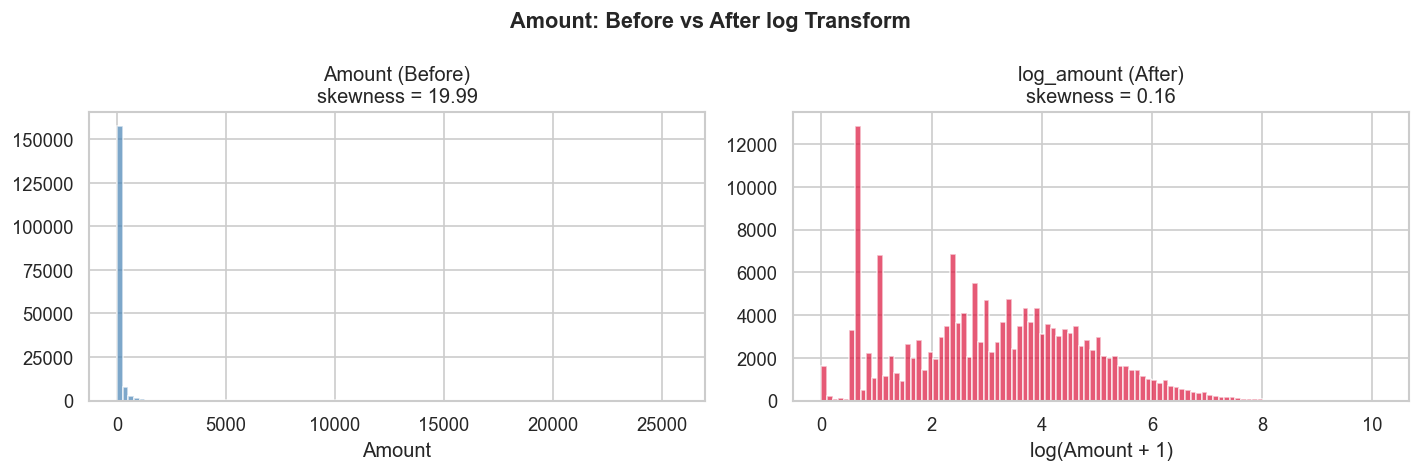

In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — Verify log_amount
# ═══════════════════════════════════════════════════════════
from scipy.stats import skew

amount_skew_before = skew(X_train["Amount"])
amount_skew_after  = skew(X_train_eng["log_amount"])

print(f"  Amount skewness (before) : {amount_skew_before:.4f}")
print(f"  Amount skewness (after)  : {amount_skew_after:.4f}")
print(f"  Reduction                : {abs(amount_skew_before) - abs(amount_skew_after):.4f}")

if abs(amount_skew_after) < abs(amount_skew_before):
    print(f"\n  ✅ log_amount reduced skewness successfully")
else:
    print(f"\n  ⚠️  Skewness not reduced — review transform")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train["Amount"],         bins=100,
             color="steelblue", alpha=0.7)
axes[0].set_title(f"Amount (Before)\nskewness = {amount_skew_before:.2f}")
axes[0].set_xlabel("Amount")

axes[1].hist(X_train_eng["log_amount"], bins=100,
             color="crimson", alpha=0.7)
axes[1].set_title(f"log_amount (After)\nskewness = {amount_skew_after:.2f}")
axes[1].set_xlabel("log(Amount + 1)")

plt.suptitle("Amount: Before vs After log Transform",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/amount_transform_verification.png",
            dpi=150, bbox_inches="tight")
plt.show()

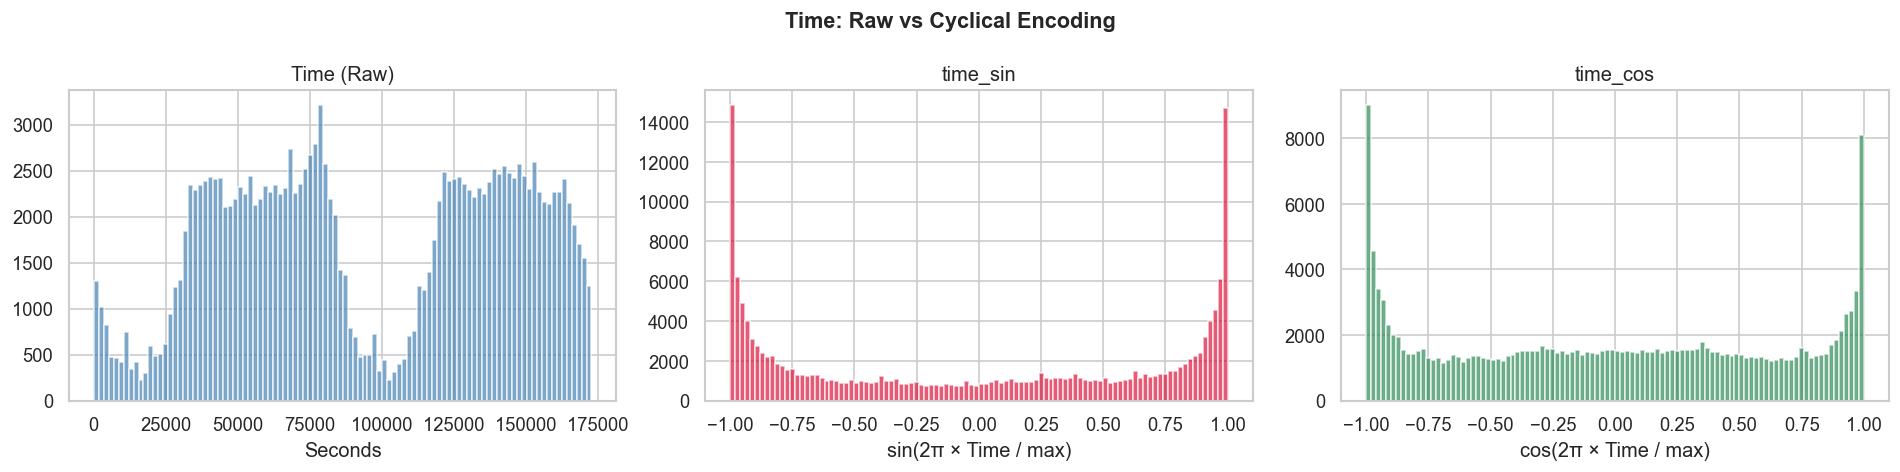

  time_sin range : [-1.0000, 1.0000]
  time_cos range : [-1.0000, 1.0000]

  ✅ Both should be in range [-1, 1]

  sin²+cos² mean : 1.000000  (should be 1.0)
  sin²+cos² std  : 0.000000   (should be ~0.0)


In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — Verify time_sin and time_cos
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Raw Time
axes[0].hist(X_train["Time"], bins=100,
             color="steelblue", alpha=0.7)
axes[0].set_title("Time (Raw)")
axes[0].set_xlabel("Seconds")

# Plot 2: time_sin
axes[1].hist(X_train_eng["time_sin"], bins=100,
             color="crimson", alpha=0.7)
axes[1].set_title("time_sin")
axes[1].set_xlabel("sin(2π × Time / max)")

# Plot 3: time_cos
axes[2].hist(X_train_eng["time_cos"], bins=100,
             color="seagreen", alpha=0.7)
axes[2].set_title("time_cos")
axes[2].set_xlabel("cos(2π × Time / max)")

plt.suptitle("Time: Raw vs Cyclical Encoding",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/time_transform_verification.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Sanity checks
print(f"  time_sin range : [{X_train_eng['time_sin'].min():.4f}, {X_train_eng['time_sin'].max():.4f}]")
print(f"  time_cos range : [{X_train_eng['time_cos'].min():.4f}, {X_train_eng['time_cos'].max():.4f}]")
print(f"\n  ✅ Both should be in range [-1, 1]")

# Check sin² + cos² = 1 (mathematical verification)
check = (X_train_eng["time_sin"]**2 + X_train_eng["time_cos"]**2)
print(f"\n  sin²+cos² mean : {check.mean():.6f}  (should be 1.0)")
print(f"  sin²+cos² std  : {check.std():.6f}   (should be ~0.0)")

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — StandardScaler 
# ═══════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on Train — never on Val or Test
X_train_scaled = scaler.fit_transform(X_train_eng)

print(f"  X_train_scaled shape : {X_train_scaled.shape}")
print(f"  Type                 : {type(X_train_scaled)}")

# Verify scaling — each feature should have mean≈0 and std≈1
means = X_train_scaled.mean(axis=0)
stds  = X_train_scaled.std(axis=0)

print(f"\n  Mean (should be ≈ 0) : min={means.min():.6f} | max={means.max():.6f}")
print(f"  Std  (should be ≈ 1) : min={stds.min():.6f}  | max={stds.max():.6f}")

if abs(means).max() < 1e-10 and abs(stds - 1).max() < 1e-10:
    print(f"\n  ✅ Scaling verified successfully")

  X_train_scaled shape : (170884, 31)
  Type                 : <class 'numpy.ndarray'>

  Mean (should be ≈ 0) : min=-0.000000 | max=0.000000
  Std  (should be ≈ 1) : min=1.000000  | max=1.000000

  ✅ Scaling verified successfully


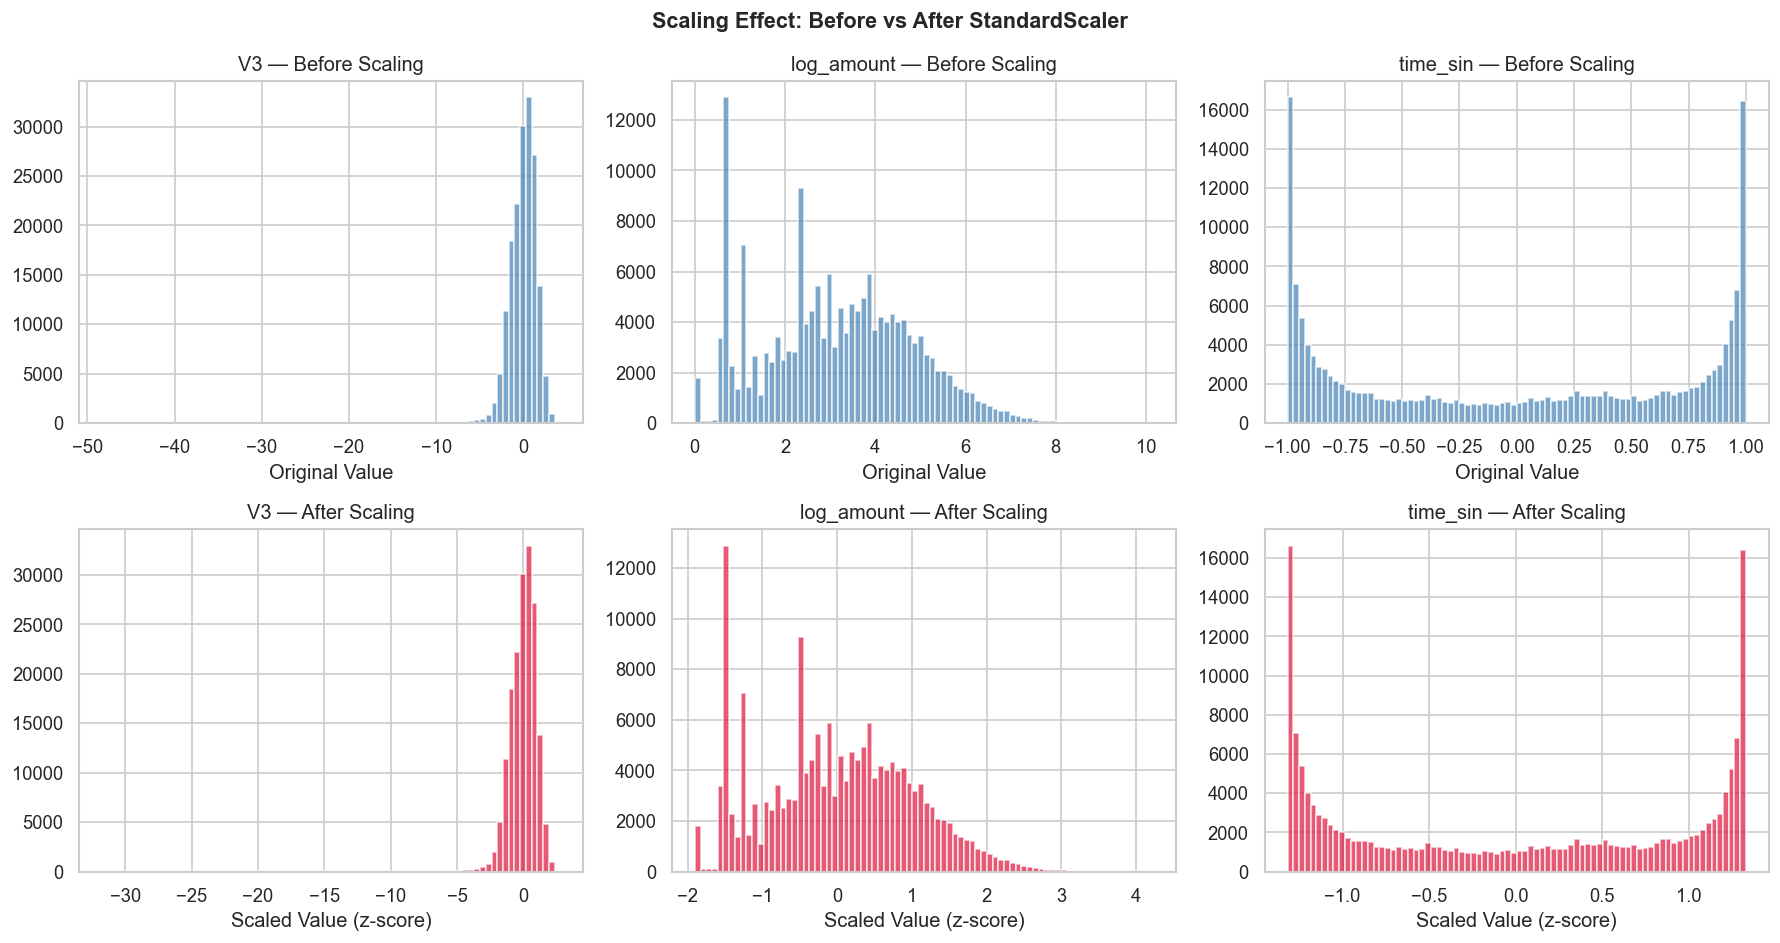

In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — Visualize Scaling Effect on key features
# ═══════════════════════════════════════════════════════════
feature_names = list(X_train_eng.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# Show 3 features before and after scaling
sample_features = ["V3", "log_amount", "time_sin"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(sample_features):
    # Before scaling
    axes[0, i].hist(X_train_eng[col], bins=80,
                    color="steelblue", alpha=0.7)
    axes[0, i].set_title(f"{col} — Before Scaling")
    axes[0, i].set_xlabel("Original Value")

    # After scaling
    axes[1, i].hist(X_train_scaled_df[col], bins=80,
                    color="crimson", alpha=0.7)
    axes[1, i].set_title(f"{col} — After Scaling")
    axes[1, i].set_xlabel("Scaled Value (z-score)")

plt.suptitle("Scaling Effect: Before vs After StandardScaler",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/scaling_verification.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — Save Final Feature Names
# ═══════════════════════════════════════════════════════════
feature_names = list(X_train_eng.columns)

print(f"  Total features : {len(feature_names)}")
print(f"  Features       : {feature_names}")

# Save to file for use in production code
import json
with open("../outputs/reports/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

print(f"\n  ✅ Feature names saved → outputs/reports/feature_names.json")

  Total features : 31
  Features       : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_amount', 'time_sin', 'time_cos']

  ✅ Feature names saved → outputs/reports/feature_names.json


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — Feature Engineering Summary
# ═══════════════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING — FINAL SUMMARY                  ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRANSFORMATIONS APPLIED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ log_amount  = log1p(Amount)
    → Skewness reduced: 19.99 → 0.16

 ✅ time_sin = sin(2π × Time / Time.max())
 ✅ time_cos = cos(2π × Time / Time.max())
    → Cyclical encoding — no fixed reference assumed
    → sin² + cos² = 1.0 verified ✅

 ❌ Amount  → Dropped (replaced by log_amount)
 ❌ Time    → Dropped (replaced by time_sin, time_cos)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SCALING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ StandardScaler fitted on Train ONLY
 ✅ Mean ≈ 0 and Std ≈ 1 for all features verified

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FINAL DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Before : (170884, 30) — V1-V28 + Amount + Time
 After  : (170884, 31) — V1-V28 + log_amount
                                + time_sin
                                + time_cos

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 IMPORTANT NOTES FOR PRODUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ⚠️  apply_feature_engineering() must be applied
     to Val and Test BEFORE scaling

 ⚠️  StandardScaler must be fitted on Train ONLY
     then transform() on Val and Test

 ⚠️  Time.max() used in cyclical encoding must be
     the Train max — not Val or Test max
""")


╔══════════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING — FINAL SUMMARY                  ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRANSFORMATIONS APPLIED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ log_amount  = log1p(Amount)
    → Skewness reduced: 19.99 → 0.16

 ✅ time_sin = sin(2π × Time / Time.max())
 ✅ time_cos = cos(2π × Time / Time.max())
    → Cyclical encoding — no fixed reference assumed
    → sin² + cos² = 1.0 verified ✅

 ❌ Amount  → Dropped (replaced by log_amount)
 ❌ Time    → Dropped (replaced by time_sin, time_cos)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 SCALING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ StandardScaler fitted on Train ONLY
 ✅ Mean ≈ 0 and Std ≈ 1 for all features verified

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FINAL DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Before : (170884, 30